# 03 · Resultados comparativos por MAE e análise dos resíduos
**Grupo 4 · MLP Regressor · base do Grupo 1 (Daily Delhi Climate)**

Avaliação **fora da amostra** (22 previsões, walk-forward, h = 1 dia, 03/04/2017 a 24/04/2017) com os hiperparâmetros fixados no notebook 02.
Todos os modelos usam as mesmas origens, o mesmo horizonte e o mesmo conjunto de teste.

In [1]:
import sys, json, warnings
sys.path.insert(0, '../src')
import numpy as np, pandas as pd
from scipy import stats
import tsutils as tu, plots as pl
warnings.filterwarnings('ignore')
R = '../results/'
P = pd.read_csv(R + 'previsoes_walkforward.csv', parse_dates=['data'])
MODELS = pl.MODELS; REF = 'Persistência (ref.)'
REFS = [REF, 'Média móvel 7d (ref.)', 'Sazonal ingênuo m=7 (ref.)']
display(P.round(3).head(8))
print('n previsões:', len(P), '| de', P.data.min().date(), 'a', P.data.max().date())

n previsões: 22 | de 2017-04-03 a 2017-04-24


,data,real,Persistência (ref.),Sazonal ingênuo m=7 (ref.),Média móvel 7d (ref.),Holt-Winters,SARIMAX,Random Forest,MLP Regressor
0,2017-04-03,30.5,29.75,29.5,30.2,30.21,30.26,29.53,29.45
1,2017-04-04,30.93,30.5,29.89,30.35,30.75,31.22,30.7,30.29
2,2017-04-05,29.23,30.93,31,30.5,31.2,30.85,30.59,30.5
3,2017-04-06,31.22,29.23,29.29,30.24,29.67,30.29,29.22,29.87
4,2017-04-07,27,31.22,30.62,30.52,31.33,30.95,31.22,31.39
5,2017-04-08,25.62,27,31.38,30,27.73,29,27.06,28.04
6,2017-04-09,27.12,25.62,29.75,29.18,25.95,25.94,24.91,25.27
7,2017-04-10,27.86,27.12,30.5,28.8,27.15,26.18,26.7,27.14


## 1. MAE dos quatro modelos e das referências
O MAE é calculado sobre as previsões fora da amostra do walk-forward. (Existe uma única base neste arquivo; por isso não há agregação de MAE entre bases, o que o enunciado proíbe quando as escalas diferem.)

In [2]:
rows = []
for m in MODELS + REFS:
    e = (P.real - P[m]).values
    rows.append(dict(modelo=m, MAE=tu.mae(P.real, P[m]), RMSE=tu.rmse(P.real, P[m]), vies_medio=e.mean(), desvio_residual=e.std(ddof=1)))
T = pd.DataFrame(rows)
T['MAE vs persistência (°C)'] = T['MAE'] - T.loc[T.modelo == REF, 'MAE'].values[0]
tempos = pd.read_csv(R + 'tempos_execucao.csv', index_col=0)['segundos']
T['tempo walk-forward (s)'] = T['modelo'].map(tempos)
display(T.round(3))

,modelo,MAE,RMSE,vies_medio,desvio_residual,MAE vs persistência (°C),tempo walk-forward (s)
0,Holt-Winters,1.052,1.396,-0.153,1.42,-0.007,0.323
1,SARIMAX,1.101,1.489,-0.282,1.497,0.042,0.682
2,Random Forest,1.172,1.489,0.356,1.479,0.113,1.961
3,MLP Regressor,1.104,1.45,0.154,1.475,0.045,11.65
4,Persistência (ref.),1.059,1.38,0.102,1.409,0,NaN
5,Média móvel 7d (ref.),1.794,2.12,0.508,2.107,0.735,NaN
6,Sazonal ingênuo m=7 (ref.),2.864,3.301,1.027,3.21,1.805,NaN


Melhor modelo nesta base (menor MAE): Holt-Winters
Vitórias por modelo (1 base):  {'Holt-Winters': 1, 'SARIMAX': 0, 'Random Forest': 0, 'MLP Regressor': 0}
Posição média por modelo (1 base) = a própria posição acima


,posição,modelo,MAE,MAE vs persistência (°C)
0,1,Holt-Winters,1.052,-0.007
1,2,SARIMAX,1.101,0.042
2,3,MLP Regressor,1.104,0.045
3,4,Random Forest,1.172,0.113


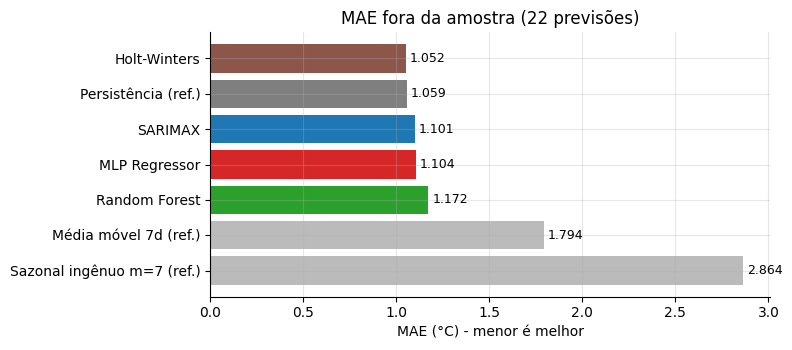

In [3]:
rank = T[T.modelo.isin(MODELS)].sort_values('MAE').reset_index(drop=True)
rank.insert(0, 'posição', rank.index + 1)
display(rank[['posição', 'modelo', 'MAE', 'MAE vs persistência (°C)']].round(3))
print('Melhor modelo nesta base (menor MAE):', rank.modelo[0])
print('Vitórias por modelo (1 base): ', {m: int(m == rank.modelo[0]) for m in MODELS})
print('Posição média por modelo (1 base) = a própria posição acima')
pl.mae_bars(T.sort_values('MAE').reset_index(drop=True))

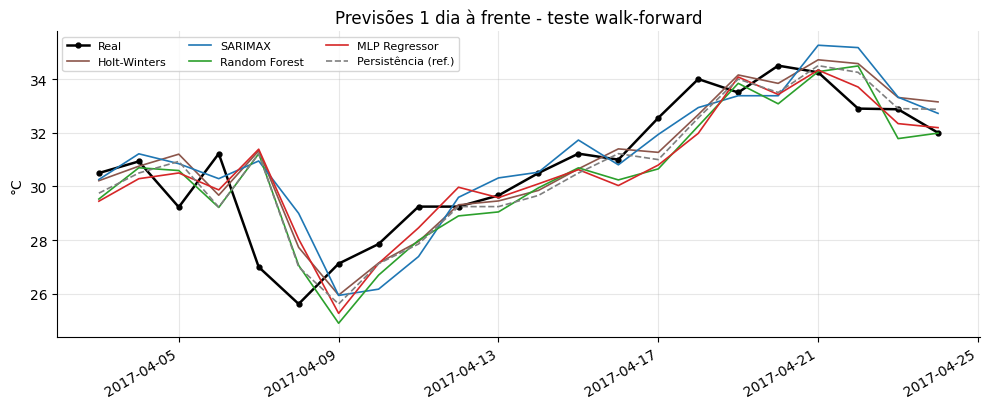

In [4]:
pl.forecasts(P)

## 2. A diferença é estatisticamente relevante?
Com apenas 22 previsões, diferenças de poucos centésimos de °C podem ser acaso. Por isso, além do ranking, usamos (i) o teste de **Diebold-Mariano** (h=1, perda absoluta, correção de Harvey-Leybourne-Newbold)
e (ii) um **bootstrap pareado** da diferença de erro absoluto em relação à persistência (5.000 reamostragens, semente fixa).

In [5]:
ep = (P.real - P[REF]).values; rng = np.random.default_rng(0)
rows = []
for m in MODELS:
    em = (P.real - P[m]).values
    dm, p = tu.diebold_mariano(ep, em)
    d = np.abs(em) - np.abs(ep)
    bs = [d[rng.integers(0, len(d), len(d))].mean() for _ in range(5000)]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    rows.append(dict(modelo=m, ΔMAE_vs_persistência=d.mean(), IC95_bootstrap=f'[{lo:.3f}; {hi:.3f}]', DM=dm, p_valor_DM=p,
                     veredito='sem diferença significativa' if p > 0.05 else ('melhor' if d.mean() < 0 else 'pior')))
display(pd.DataFrame(rows).round(3))
rows = []
for a in MODELS:
    for b in MODELS:
        if a < b:
            dm, p = tu.diebold_mariano((P.real - P[a]).values, (P.real - P[b]).values)
            rows.append(dict(par=f'{a} vs {b}', DM=dm, p_valor=p))
display(pd.DataFrame(rows).round(3))

,modelo,ΔMAE_vs_persistência,IC95_bootstrap,DM,p_valor_DM,veredito
0,Holt-Winters,-0.007,[-0.133; 0.120],0.105,0.917,sem diferença significativa
1,SARIMAX,0.042,[-0.228; 0.338],-0.275,0.786,sem diferença significativa
2,Random Forest,0.113,[-0.053; 0.280],-1.255,0.223,sem diferença significativa
3,MLP Regressor,0.045,[-0.150; 0.238],-0.421,0.678,sem diferença significativa


,par,DM,p_valor
0,Holt-Winters vs SARIMAX,-0.422,0.678
1,Holt-Winters vs Random Forest,-1.031,0.314
2,Holt-Winters vs MLP Regressor,-0.463,0.648
3,Random Forest vs SARIMAX,0.426,0.675
4,MLP Regressor vs SARIMAX,0.019,0.985
5,MLP Regressor vs Random Forest,-0.739,0.468


**Leitura.** O Holt-Winters tem o menor MAE numérico (≈ 1,05 °C), com a persistência logo atrás (≈ 1,06) e SARIMAX (≈ 1,10), **MLP (≈ 1,10)** e Random Forest (≈ 1,17) em seguida.
Porém **nenhuma diferença em relação à persistência é significativa** (todos os p do DM ≥ 0,22; todos os ICs do bootstrap contêm 0), e as comparações entre os quatro modelos também não discriminam.
A conclusão honesta é um **empate técnico**: nesta janela de 22 dias, nenhum dos modelos demonstra superar a regra "amanhã = hoje".
Isto **não é um defeito do ajuste**, e sim uma propriedade da base: a temperatura diária tem ACF(1) ≈ 0,95, a variação diária é pouco previsível (ACF de Δy pequena) e as exógenas trazem pouco sinal (notebook 01).
O erro de ≈ 1 °C é compatível com o piso de ruído meteorológico (desvio-padrão do resíduo STL ≈ 1,5 °C).

Visualmente (figura acima), todas as curvas previstas parecem a série real **deslocada em 1 dia**: é o efeito de "atraso" típico de modelos que se apoiam no último valor observado. Eles acompanham a tendência, mas não antecipam reversões (como a queda de 07/04).

O ranking numérico é registrado conforme pedido, mas **não deve ser lido como superioridade comprovada**. Pela falta de significância, todas as comparações aqui são descritivas.

## 3. Onde cada modelo erra: extrapolação
O teste cai no pico de aquecimento: 8 dos 22 alvos (36%) excedem o **máximo do treino (31,4 °C)**. Modelos de árvore não extrapolam; redes com alvo em Δ extrapolam de forma limitada.
Viés = média de (real − previsto): **positivo = subestima**, negativo = superestima.

In [6]:
D = tu.clean(tu.load_raw()); trmax = D.meantemp[:92].max()
hi = (P.real > trmax).values
rows = []
for m in MODELS + [REF]:
    e = (P.real - P[m]).values
    rows.append(dict(modelo=m, alvos_acima_do_max_treino=int(hi.sum()), MAE_acima=np.abs(e[hi]).mean(), MAE_dentro=np.abs(e[~hi]).mean(),
                     viés_acima=e[hi].mean(), viés_dentro=e[~hi].mean()))
display(pd.DataFrame(rows).round(3))
print('máximo do alvo no treino:', round(trmax, 2), '°C | máximo no teste:', round(P.real.max(), 2), '°C')

máximo do alvo no treino: 31.38 °C | máximo no teste: 34.5 °C


,modelo,alvos_acima_do_max_treino,MAE_acima,MAE_dentro,viés_acima,viés_dentro
0,Holt-Winters,8,0.957,1.106,-0.139,-0.162
1,SARIMAX,8,0.922,1.203,-0.192,-0.333
2,Random Forest,8,1.017,1.261,0.528,0.258
3,MLP Regressor,8,0.88,1.232,0.466,-0.025
4,Persistência (ref.),8,0.875,1.164,0.125,0.089


**Leitura.** O **Random Forest tem viés positivo** (subestima) tanto dentro quanto acima da faixa do treino, e **mais nos dias acima do máximo do treino** (≈ +0,53 °C): as folhas das árvores só devolvem médias de valores já vistos.
O **MLP é praticamente sem viés dentro da faixa (≈ −0,03 °C)** e subestima ≈ +0,47 °C nos dias acima do máximo, o que mostra o limite de extrapolação de uma rede com ativação ReLU e forte regularização.
Holt-Winters e SARIMAX têm componente de tendência e tendem a **superestimar** levemente (viés negativo), enquanto a persistência subestima um pouco (viés ≈ +0,10), como esperado em série em alta.
Com 22 pontos, **nenhum dos vieses médios é estatisticamente diferente de zero** (teste t, p > 0,27): são tendências, não achados.

## 4. Análise dos resíduos (erros fora da amostra = real − previsto)
Para cada modelo: resíduo no tempo, ACF, teste de Ljung-Box e discussão de viés/padrões/variabilidade.
O Ljung-Box usa lags 5 e 10 (graus de liberdade = lag, pois os resíduos são de previsão fora da amostra e não de ajuste). **Atenção:** com n = 22, o lag 10 é grande e o teste tem **baixo poder**.

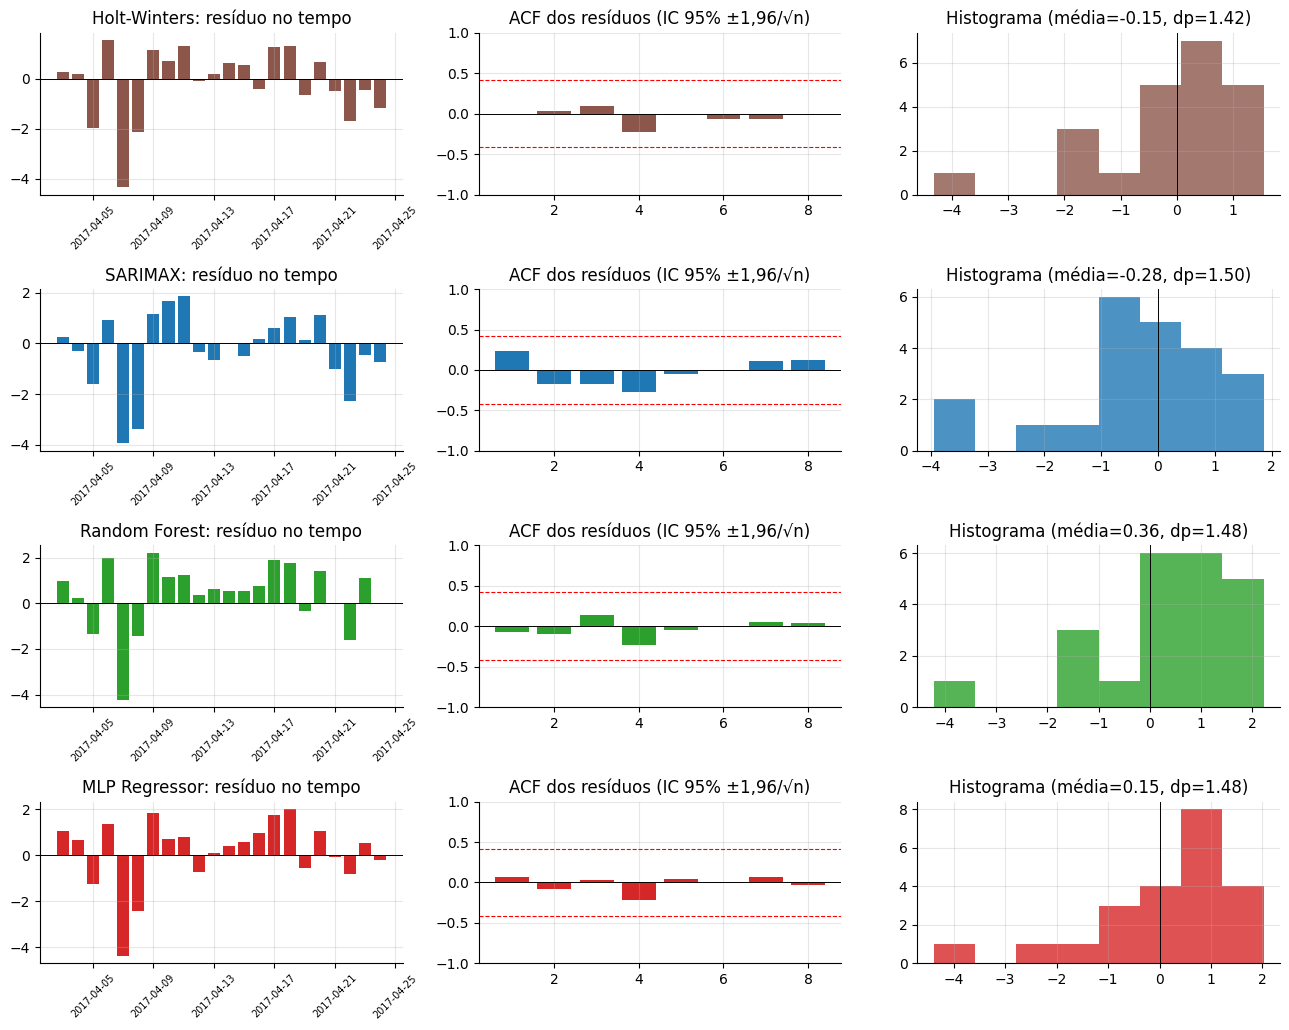

In [7]:
pl.residual_panels(P)

In [8]:
lb = []
for m in MODELS:
    e = (P.real - P[m]).values
    t = tu.ljung_box(e, [5, 10]).set_index('lag')
    tt = stats.ttest_1samp(e, 0)
    lb.append(dict(modelo=m, **{'Q(5)': t.loc[5, 'Q'], 'p(5)': t.loc[5, 'p_valor'], 'Q(10)': t.loc[10, 'Q'], 'p(10)': t.loc[10, 'p_valor']},
                   ACF_lag1=tu.acf(e, 1)[1], viés=e.mean(), p_viés=tt.pvalue, desvio=e.std(ddof=1),
                   conclusão='sem evidência de autocorrelação' if min(t.p_valor) > 0.05 else 'AUTOCORRELAÇÃO residual'))
LB = pd.DataFrame(lb); display(LB.round(3))
print('Limite de significância da ACF (95%%): ±%.2f' % (1.96 / np.sqrt(len(P))))

Limite de significância da ACF (95%): ±0.42


,modelo,Q(5),p(5),Q(10),p(10),ACF_lag1,viés,p_viés,desvio,conclusão
0,Holt-Winters,1.827,0.873,5.482,0.857,-0.007,-0.153,0.618,1.42,sem evidência de autocorrelação
1,SARIMAX,5.333,0.377,6.785,0.746,0.234,-0.282,0.387,1.497,sem evidência de autocorrelação
2,Random Forest,2.688,0.748,4.9,0.898,-0.072,0.356,0.271,1.479,sem evidência de autocorrelação
3,MLP Regressor,1.775,0.879,5.378,0.865,0.065,0.154,0.63,1.475,sem evidência de autocorrelação


### Interpretação
- **Autocorrelação:** em todos os modelos, **p(5) e p(10) ficam acima de 0,37**: o Ljung-Box **não rejeita ruído branco**, e nenhuma ACF ultrapassa o limite de ±0,42. O SARIMAX tem a maior ACF no lag 1 (≈ 0,23), ainda dentro do limite.
  Interpretação: os modelos já extraem a informação linear de curto prazo que existe; o que sobra parece ruído. Ressalva: com n = 22 a **ausência de rejeição não prova** ausência de estrutura (baixo poder).
- **Viés:** pequeno e não significativo para todos (|viés| ≤ 0,36 °C, p > 0,27). O RF é o único com viés relativamente maior (≈ +0,36 °C, subestimação), explicado pela extrapolação (seção 3).
- **Variabilidade:** o desvio-padrão dos resíduos é de ≈ 1,4-1,5 °C em todos os modelos e muito próximo ao da persistência (≈ 1,41), reforçando que a parte previsível é pequena.
- **Padrões remanescentes (leitura dos gráficos):** não há tendência nos erros ao longo do tempo, mas os histogramas são **assimétricos, com cauda à esquerda**: um único dia, **07/04/2017**
  (a temperatura cai de 31,2 para 27,0 °C), produz erro de ≈ −4 °C em **todos** os modelos, seguido de erros negativos em 08/04. É uma **queda brusca imprevisível** a partir do histórico e das exógenas disponíveis.
  A análise abaixo quantifica o efeito.

In [9]:
E = pd.DataFrame({m: P.real - P[m] for m in MODELS + [REF]}); E.index = P.data.dt.date
worst = E.abs().idxmax().mode()[0]
print('dia de maior erro absoluto (comum a todos os modelos e à persistência):', worst)
q = pd.DataFrame({'erro nesse dia (°C)': E.loc[worst], 'contribuição ao MAE (°C)': E.loc[worst].abs() / len(E),
                  'MAE com o dia': E.abs().mean(), 'MAE sem o dia': E.drop(worst).abs().mean()})
display(q.round(3))
print('Correlação entre os resíduos dos modelos:'); display(E.corr().round(2))

dia de maior erro absoluto (comum a todos os modelos e à persistência): 2017-04-07
Correlação entre os resíduos dos modelos:


,erro nesse dia (°C),contribuição ao MAE (°C),MAE com o dia,MAE sem o dia
Holt-Winters,-4.328,0.197,1.052,0.896
SARIMAX,-3.95,0.18,1.101,0.965
Random Forest,-4.221,0.192,1.172,1.027
MLP Regressor,-4.388,0.199,1.104,0.948
Persistência (ref.),-4.222,0.192,1.059,0.908


,Holt-Winters,SARIMAX,Random Forest,MLP Regressor,Persistência (ref.)
Holt-Winters,1,0.91,0.96,0.93,0.99
SARIMAX,0.91,1,0.9,0.88,0.88
Random Forest,0.96,0.9,1,0.96,0.96
MLP Regressor,0.93,0.88,0.96,1,0.93
Persistência (ref.),0.99,0.88,0.96,0.93,1


**Leitura.** (i) Esse único dia responde por ≈ 0,18-0,20 °C do MAE de cada modelo (cerca de 16-19% do erro); sem ele, os MAE caem para ≈ 0,90-1,03 °C. O Holt-Winters segue em 1º e o Random Forest em último, mas **SARIMAX e MLP trocam de posição** (MLP 0,948 × SARIMAX 0,965): mais um sinal de que o ranking intermediário é instável.
(ii) Os resíduos dos modelos são **fortemente correlacionados entre si (0,88-0,99)**: o erro é dominado por choques meteorológicos comuns que nenhum modelo antecipa, e não por diferenças de especificação.
Isto reforça o "empate técnico" da seção 2 e explica por que testes de acurácia entre modelos têm tão pouco poder aqui.

## 5. Quais características da base explicam o desempenho?
| Característica da base | Efeito observado |
|---|---|
| Alta inércia (ACF(1)≈0,95) | Persistência é uma referência muito forte; difícil superá-la em h=1 |
| Tendência dominante (≈91% da variância) | Favorece modelos com tendência (Holt-Winters, SARIMAX com d=1); penaliza quem prevê o nível sem extrapolar (RF) |
| Sazonalidade semanal fraca (F≈0,12) | Sem ganho com componente sazonal; a melhor configuração de HW e SARIMAX **descarta** a sazonalidade |
| Poucos dados (92 alvos de treino; < 1 ciclo anual) | Modelos flexíveis (RF, MLP) têm pouca informação; o MLP precisa de L2 forte, o que o aproxima da persistência |
| Teste fora da faixa do treino (36% acima do máximo) | Expõe a incapacidade de extrapolação do RF e limita o MLP |
| Exógenas com sinal fraco | Pouco ganho das variáveis externas (detalhado no notebook 04) |

## 6. Conclusões e limitações deste notebook
1. Nenhum modelo supera de forma comprovada a persistência; o Holt-Winters tem o menor MAE numérico e o ranking está registrado, com a ressalva de significância.
2. Os resíduos não apresentam autocorrelação detectável (Ljung-Box), o que é coerente com modelos que já esgotaram a informação linear disponível, ressalvado o baixo poder do teste.
3. **Limitações:** uma única base; 22 previsões; ranking instável; sem retreinamento de hiperparâmetros durante o teste (por desenho do protocolo). Resultados **não se generalizam** para as outras quatro bases do enunciado.